# GWL Figure: SSP comparison
Reproduces spirit of `figure_ssps_gwls.ipynb` using raw CMIP6 tas GMST timeseries.

In [1]:
import sys, os
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
os.chdir('/burg-archive/home/mck2199/summer/bcd_me/code')

import xarray as xr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import patches as mpatches
import warnings

from funcs_support import get_params
dir_list = get_params()

In [2]:
ds = xr.open_dataset(dir_list['aux'] + 'gwl_ann_CMIP6_ALLEXPs_ALLRUNs_1860-2090_fromAmon.nc').load()

colors = {
    'ssp126': '#003466',
    'ssp245': '#f69320',
    'ssp370': '#df0000',
    'ssp585': '#980002',
}
# Match BCD-ME preprint figure_ssps_gwls.ipynb (exps_plot)
exps = ['ssp245', 'ssp370', 'ssp585']
gwl_targets = [1.0, 1.5, 2.0, 3.0]
print(ds)

<xarray.Dataset> Size: 323kB
Dimensions:     (year: 232, memberid: 84, bnds: 2)
Coordinates:
  * year        (year) int64 2kB 1860 1861 1862 1863 ... 2088 2089 2090 2091
    model       (memberid) <U13 4kB 'CanESM5' 'CanESM5' ... 'MPI-ESM1-2-LR'
    experiment  (memberid) <U6 2kB 'ssp370' 'ssp126' ... 'ssp126' 'ssp370'
    run         (memberid) <U8 3kB 'r1i1p1f1' 'r1i1p1f1' ... 'r5i1p1f1'
  * bnds        (bnds) float64 16B 1.0 2.0
    height      float64 8B 2.0
Dimensions without coordinates: memberid
Data variables:
    tas         (year, memberid) float64 156kB 286.7 286.7 286.7 ... 288.2 290.1
    tasanom     (year, memberid) float64 156kB -0.04551 -0.04551 ... 1.487 3.418
Attributes: (12/54)
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH

In [3]:
# Compute year of GWL crossing for each member
rows = []
for i in range(ds.sizes['memberid']):
    mem = ds.isel(memberid=i)
    mod = str(mem.model.values)
    exp = str(mem.experiment.values)
    for g in gwl_targets:
        cross = mem.year.where(mem.tasanom >= g).min()
        yr = int(cross) if not np.isnan(float(cross)) else np.nan
        rows.append({'model': mod, 'experiment': exp, 'gwl': g, 'year_crossed': yr})
df_cross = pd.DataFrame(rows)
print(df_cross.pivot_table(index=['model','experiment'], columns='gwl', values='year_crossed'))

gwl                               1.0          1.5          2.0     3.0
model         experiment                                               
CanESM5       ssp126      2000.400000  2011.800000  2023.600000     NaN
              ssp245      2000.400000  2011.400000  2022.800000  2047.8
              ssp370      2000.400000  2011.800000  2021.600000  2042.2
              ssp585      2000.400000  2011.600000  2021.800000  2040.0
GFDL-ESM4     ssp126      2021.000000          NaN          NaN     NaN
              ssp245      2015.666667  2043.666667  2068.000000     NaN
              ssp370      2022.000000  2042.000000  2058.000000  2084.0
              ssp585      2022.000000  2040.000000  2053.000000  2076.0
IPSL-CM6A-LR  ssp126      2003.600000  2019.400000  2037.400000     NaN
              ssp245      2002.200000  2018.400000  2033.600000  2065.2
              ssp370      2002.200000  2019.400000  2033.600000  2055.6
              ssp585      2003.600000  2019.400000  2032.800000 

/local/ipykernel_511837/3211831596.py:44: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, positions=[x], widths=bar_width * 0.8,
/local/ipykernel_511837/3211831596.py:44: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, positions=[x], widths=bar_width * 0.8,
/local/ipykernel_511837/3211831596.py:44: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, positions=[x], widths=bar_width * 0.8,
/local/ipykernel_511837/3211831596.py:44: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxpl

saved


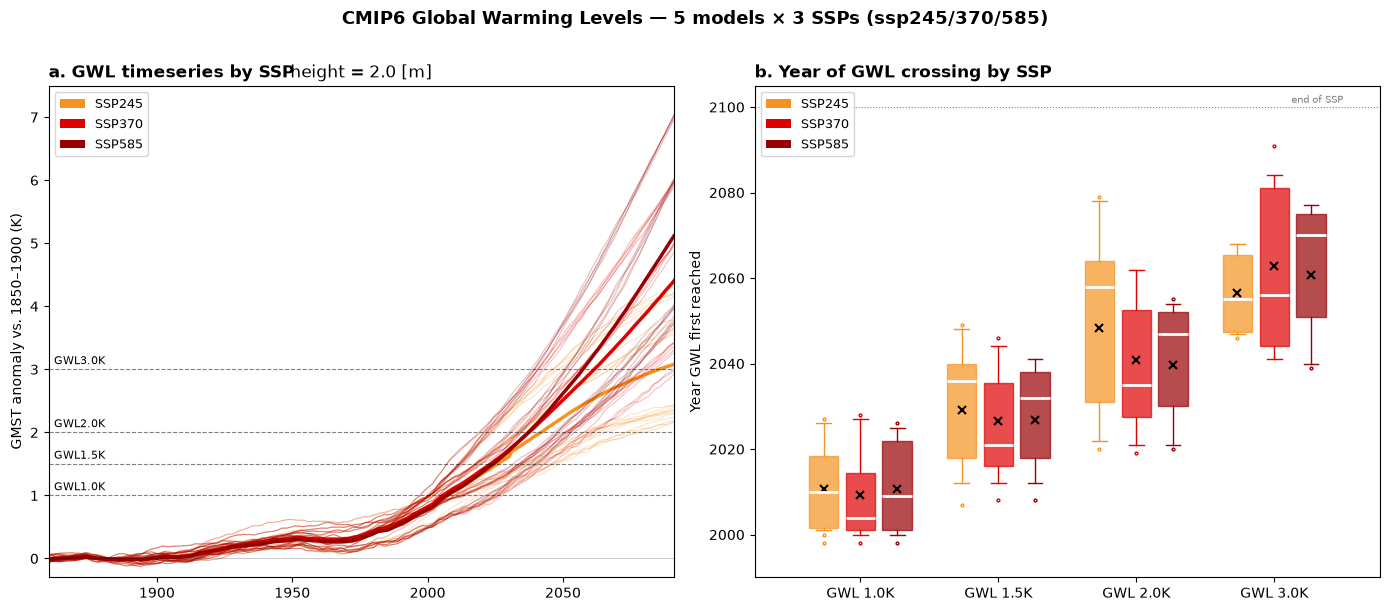

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel A: GWL timeseries ──────────────────────────────────────────────────
ax = axes[0]
for exp in exps:
    mask = ds.experiment.values == exp
    sub = ds.isel(memberid=np.where(mask)[0])
    # individual runs
    for i in range(sub.sizes['memberid']):
        sub.isel(memberid=i).tasanom.plot(
            ax=ax, color=colors[exp], alpha=0.25, linewidth=0.8, add_legend=False)
    # ensemble mean
    sub.tasanom.mean('memberid').plot(
        ax=ax, color=colors[exp], linewidth=2.5,
        label=exp.upper(), add_legend=False)

# GWL threshold lines
for g in gwl_targets:
    ax.axhline(g, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(1862, g + 0.04, f'GWL{g}K', fontsize=8, va='bottom')

ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_xlim(1860, 2091)
ax.set_ylim(-0.3, 7.5)
ax.set_ylabel('GMST anomaly vs. 1850–1900 (K)')
ax.set_xlabel('')
ax.set_title('a. GWL timeseries by SSP', fontweight='bold', loc='left')
ax.legend(handles=[mpatches.Patch(facecolor=colors[e], label=e.upper()) for e in exps],
          loc='upper left', fontsize=9)

# ── Panel B: Year of GWL crossing ────────────────────────────────────────────
ax = axes[1]
n_gwls = len(gwl_targets)
n_exps = len(exps)
group_width = 0.8
bar_width = group_width / n_exps

for g_idx, g in enumerate(gwl_targets):
    for e_idx, exp in enumerate(exps):
        data = df_cross.query(f'gwl == {g} and experiment == "{exp}"')['year_crossed'].dropna()
        if len(data) == 0:
            continue
        x = g_idx + (e_idx - n_exps/2 + 0.5) * bar_width
        bp = ax.boxplot(data, positions=[x], widths=bar_width * 0.8,
                        patch_artist=True, vert=True,
                        whis=[5, 95],
                        flierprops={'marker': '.', 'markersize': 4},
                        medianprops={'color': 'white', 'linewidth': 2})
        for item in ['boxes', 'whiskers', 'fliers', 'caps']:
            plt.setp(bp[item], color=colors[exp])
        plt.setp(bp['boxes'], facecolor=colors[exp], alpha=0.7)
        plt.setp(bp['fliers'], markeredgecolor=colors[exp])
        # model mean
        ax.plot(x, data.mean(), 'x', color='k', markersize=6, markeredgewidth=1.5)

ax.set_xticks(range(n_gwls))
ax.set_xticklabels([f'GWL {g}K' for g in gwl_targets])
ax.set_ylabel('Year GWL first reached')
ax.set_title('b. Year of GWL crossing by SSP', fontweight='bold', loc='left')
ax.legend(handles=[mpatches.Patch(facecolor=colors[e], label=e.upper()) for e in exps],
          loc='upper left', fontsize=9)
ax.set_ylim(1990, 2105)
ax.axhline(2100, color='grey', linestyle=':', linewidth=0.8)
ax.text(n_gwls - 0.5, 2101, 'end of SSP', fontsize=7, color='grey', ha='right')

plt.suptitle(
    f'CMIP6 Global Warming Levels — {len(np.unique(ds.model.values))} models × 3 SSPs (ssp245/370/585)',
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

out = dir_list['aux'] + '../figures/'
os.makedirs(out, exist_ok=True)
plt.savefig(out + 'ssp_gwl_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig(out + 'ssp_gwl_comparison.pdf', bbox_inches='tight')
print('saved')
plt.show()